# ViT in the Real World: Cats vs Dogs Classification with Hugging Face

**Goal:** Show how a pretrained Vision Transformer (ViT) is used in practice — load it from the Hugging Face Hub, adapt it to a new task (cats vs dogs), fine-tune briefly, and run predictions.

**Run this in Google Colab** with a GPU runtime: `Runtime > Change runtime type > T4 GPU`.

This is the practical counterpart to the "ViT from scratch" session — here we treat ViT as a **reusable building block**, exactly how it's used in industry: download → adapt head → fine-tune → deploy.


## 1. Setup

In [1]:
!pip install -q transformers datasets torch accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.9 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
from transformers import ViTImageProcessor, ViTForImageClassification
from datasets import load_dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Load the Cats vs Dogs dataset

We use the `microsoft/cats_vs_dogs` dataset from the Hugging Face Hub. For a quick live demo we take a small subset — enough to show fine-tuning working, not to reach maximum accuracy.


README.md:   0%|          | 0.00/8.16k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/330M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

Classes: ['cat', 'dog']
Train size: 480 | Test size: 120


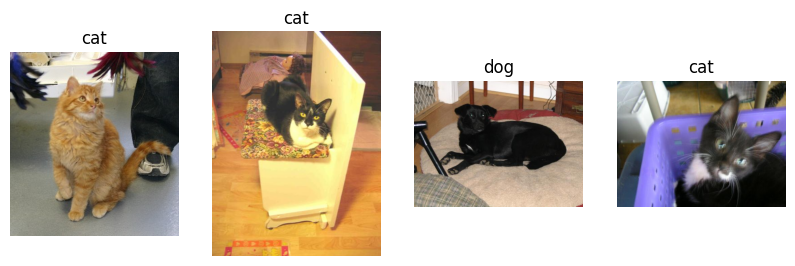

In [3]:
dataset = load_dataset("microsoft/cats_vs_dogs", split="train")
dataset = dataset.shuffle(seed=42).select(range(600))   # small subset for a fast demo

split_dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_ds, test_ds = split_dataset["train"], split_dataset["test"]

labels = dataset.features["labels"].names
print("Classes:", labels)
print("Train size:", len(train_ds), "| Test size:", len(test_ds))

# Peek at a few images
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(train_ds[i]["image"])
    ax.set_title(labels[train_ds[i]["labels"]])
    ax.axis("off")
plt.show()


In [8]:
# Select the first image from the training dataset
idx = 53
image_to_save = train_ds[idx]["image"]

# Save it to your local directory with a filename
image_to_save.save("cat_or_dog_sample.jpg")

print("Image saved successfully!")


Image saved successfully!


## 3. Load a pretrained ViT from the Hugging Face Hub

We use **`google/vit-base-patch16-224-in21k`** — a ViT-Base model (patch size 16, the exact architecture covered in the theory session) pretrained on ImageNet-21k. It comes with:

- An **`ViTImageProcessor`** — handles resizing, normalization, and patchifying exactly the way the model expects (no manual preprocessing needed).
- A **`ViTForImageClassification`** model — the pretrained backbone + a classification head we will replace for our 2 classes (cat / dog).

This is the "load → adapt head → fine-tune" workflow every real ViT application follows.


In [9]:
model_name = "google/vit-base-patch16-224-in21k"

processor = ViTImageProcessor.from_pretrained(model_name)

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label={i: l for i, l in enumerate(labels)},
    label2id={l: i for i, l in enumerate(labels)},
).to(device)

print("Patch size:", model.config.patch_size)
print("Hidden (embedding) size:", model.config.hidden_size)
print("Number of transformer layers:", model.config.num_hidden_layers)
print("Number of attention heads:", model.config.num_attention_heads)
print("New classification head:", model.classifier)


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.weight   | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight 

Patch size: 16
Hidden (embedding) size: 768
Number of transformer layers: 12
Number of attention heads: 12
New classification head: Linear(in_features=768, out_features=2, bias=True)


**Note:** `num_labels=2` automatically swaps out the pretrained 21,843-class head for a fresh `Linear(768, 2)` layer — the backbone (patch embedding + 12 transformer blocks) keeps its pretrained weights. This is the same transfer-learning idea from the theory session, just done in two lines via Hugging Face.


## 4. Preprocess the dataset

The `ViTImageProcessor` resizes images to 224×224 and normalizes pixel values the same way the model was pretrained — this consistency is essential, so always use the processor that ships with the checkpoint rather than writing your own.


In [10]:
def preprocess(batch):
    inputs = processor([img.convert("RGB") for img in batch["image"]], return_tensors="np")
    batch["pixel_values"] = [pv for pv in inputs["pixel_values"]]
    return batch

train_ds = train_ds.map(preprocess, batched=True, batch_size=32)
test_ds = test_ds.map(preprocess, batched=True, batch_size=32)

print(np.array(train_ds[0]["pixel_values"]).shape, "-> (channels, height, width), ready for the model")


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

(3, 224, 224) -> (channels, height, width), ready for the model



## 5. Fine-tune with the Hugging Face `Trainer`

The `Trainer` API handles the training loop, evaluation, and logging for us — the standard way ViT (and most Hugging Face models) is fine-tuned in practice.


In [11]:
# Took 5 minutes on TPU
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, refs = eval_pred
    preds = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=preds, references=refs)

def collate_fn(batch):
    pixel_values = torch.tensor(np.array([b["pixel_values"] for b in batch]), dtype=torch.float32)
    labels = torch.tensor([b["labels"] for b in batch])
    return {"pixel_values": pixel_values, "labels": labels}

training_args = TrainingArguments(
    output_dir="./vit-cats-vs-dogs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,          # small, just to demonstrate fine-tuning live
    eval_strategy="epoch",
    logging_steps=10,
    learning_rate=5e-5,
    remove_unused_columns=False,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,0.691155,0.703172,0.500000
2,0.688930,0.688682,0.516667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=60, training_loss=0.7051400343577067, metrics={'train_runtime': 147.1529, 'train_samples_per_second': 6.524, 'train_steps_per_second': 0.408, 'total_flos': 7.439231003000832e+16, 'train_loss': 0.7051400343577067, 'epoch': 2.0})

In [12]:
results = trainer.evaluate()
print(f"Final test accuracy: {results['eval_accuracy']*100:.2f}%")


Training Loss,Validation Loss,Epoch,Accuracy
0.688930,0.688682,2,0.516667


Final test accuracy: 51.67%


In [13]:
# Lets Retrain: Took 10 minutes

# Bump the epoch count so Trainer's internal step/epoch bookkeeping stays consistent,
# then call train() again -- it continues from the CURRENT weights of trainer.model,
# it does not reinitialize them.
training_args.num_train_epochs = 4          # 2 already done + 2 more
trainer.args = training_args

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.661584,0.681758,0.516667
2,0.691260,0.726651,0.566667
3,0.653968,0.668170,0.633333
4,0.602708,0.661444,0.633333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=120, training_loss=0.6471252799034118, metrics={'train_runtime': 311.2834, 'train_samples_per_second': 6.168, 'train_steps_per_second': 0.386, 'total_flos': 1.4878462006001664e+17, 'train_loss': 0.6471252799034118, 'epoch': 4.0})

In [ ]:
results = trainer.evaluate()
print(f"Final test accuracy: {results['eval_accuracy']*100:.2f}%")

Training Loss,Validation Loss,Epoch,Accuracy
0.618375,0.661148,4,0.633333


Final test accuracy: 63.33%


## 6. Real-world inference demo

This is what deployment looks like: take a new image, run it through the processor + model, and get a prediction — exactly what a production API endpoint would do.


Prediction: dog (52.6% confidence)


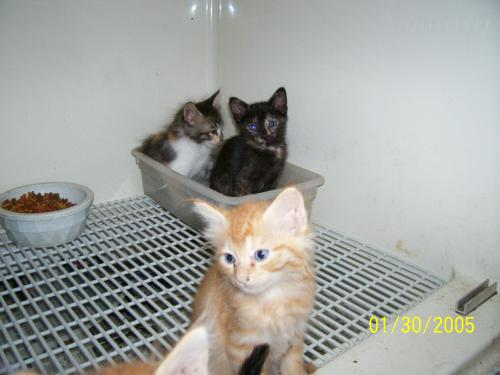

In [23]:
from PIL import Image
import requests

IDX = 0

def predict(image: Image.Image):
    inputs = processor(image.convert("RGB"), return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = logits.softmax(dim=-1)[0]
    pred_id = probs.argmax().item()
    return labels[pred_id], probs[pred_id].item()


# test on a sample from the test set
sample_img = split_dataset["test"][IDX]["image"]
# sample_img = Image.open("/content/sample_data/cat.png")

label, confidence = predict(sample_img)
print(f"Prediction: {label} ({confidence*100:.1f}% confidence)")

sample_img

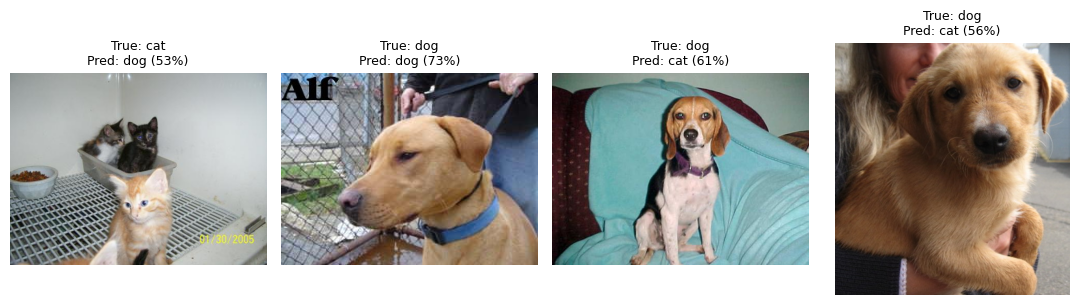

In [15]:
from PIL import Image
import requests


# Try it on a few test-set images
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for i, ax in enumerate(axes):
    img = split_dataset["test"][i]["image"]
    true_label = labels[split_dataset["test"][i]["labels"]]
    pred_label, confidence = predict(img)
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence*100:.0f}%)", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


# Evaluate

In [16]:
import numpy as np

# trainer.predict() reuses the same collate_fn, so it works with our numpy-based pixel_values too
predictions = trainer.predict(test_ds)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print("Predicted", len(y_pred), "test samples")

Predicted 120 test samples


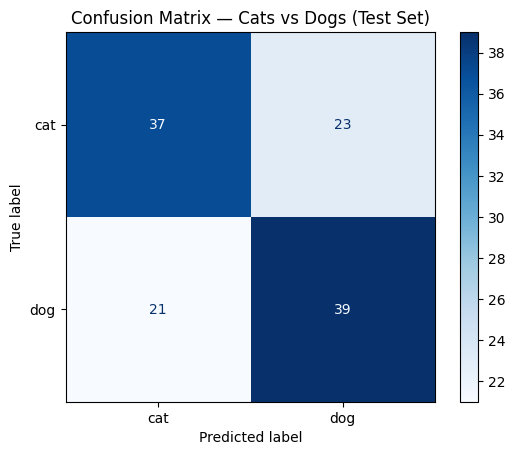

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Cats vs Dogs (Test Set)")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=labels))

              precision    recall  f1-score   support

         cat       0.64      0.62      0.63        60
         dog       0.63      0.65      0.64        60

    accuracy                           0.63       120
   macro avg       0.63      0.63      0.63       120
weighted avg       0.63      0.63      0.63       120



# 7. Now save and Load the model

In [19]:
save_path = "./vit-cats-vs-dogs-finetuned"

trainer.save_model(save_path)      # saves model weights + config
processor.save_pretrained(save_path)  # saves the matching image processor

print("Model and processor saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and processor saved to: ./vit-cats-vs-dogs-finetuned


In [20]:
from transformers import ViTImageProcessor, ViTForImageClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loaded_processor = ViTImageProcessor.from_pretrained(save_path)
loaded_model = ViTForImageClassification.from_pretrained(save_path).to(device)
loaded_model.eval()

print("Loaded model's classes:", loaded_model.config.id2label)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loaded model's classes: {0: 'cat', 1: 'dog'}


Prediction: dog (70.1% confidence)


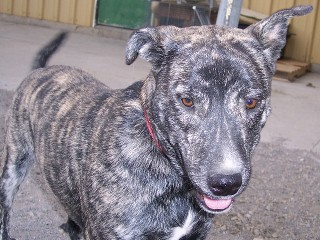

In [21]:
from PIL import Image

IDX = 10

def predict(image: Image.Image):
    inputs = processor(image.convert("RGB"), return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = logits.softmax(dim=-1)[0]
    pred_id = probs.argmax().item()
    return labels[pred_id], probs[pred_id].item()



# test on a sample from the test set
sample_img = split_dataset["test"][IDX]["image"]
label, confidence = predict(sample_img)
print(f"Prediction: {label} ({confidence*100:.1f}% confidence)")

sample_img

**Try it live:** upload your own cat/dog photo in Colab (`from google.colab import files; files.upload()`) and pass it through `predict()` — a good way to make the "real world application" point tangible to faculty.

## Key Takeaways

1. **Never train ViT from scratch for a real task** — start from a Hub checkpoint (`google/vit-base-patch16-224-in21k` here) and reuse its pretrained representations.
2. The **image processor** and **model** must always come from the same checkpoint — preprocessing must match pretraining.
3. Adapting to a new task = **swap the classification head** (`num_labels=...`) and fine-tune, usually for just a few epochs on a modest dataset.
4. The Hugging Face `Trainer` abstracts away the training loop — the same pattern works for any ViT variant (DeiT, Swin, BEiT, CLIP's vision tower, etc.) with minimal code changes.
